In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [4]:
data = pd.read_csv('datasets/heart.csv')
X = data.drop('output', axis=1)
y = data['output']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

In [6]:
y_pred = rf_model.predict(X_test)

In [7]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Random forest accuracy:", accuracy)
print("\n Classification Report: \n", report)

Random forest accuracy: 0.8688524590163934

 Classification Report: 
               precision    recall  f1-score   support

           0       0.89      0.83      0.86        29
           1       0.85      0.91      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



In [8]:
feature_importances = rf_model.feature_importances_
features = X.columns

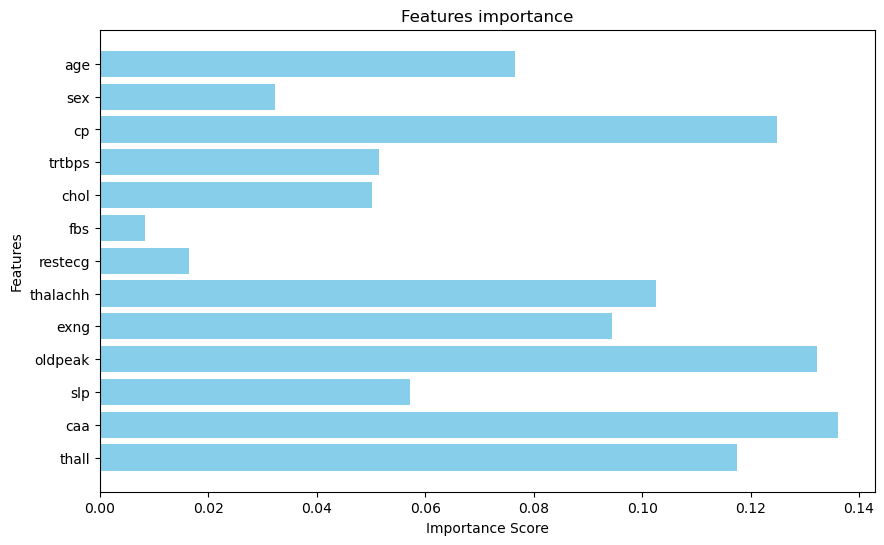

In [12]:
plt.figure(figsize=(10, 6))
plt.barh(features, feature_importances, color='skyblue')
plt.title("Features importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [ ]:
# 변수 중요도

In [14]:
import numpy as np 

feature_importance = rf_model.feature_importances_
features = X.columns

sorted_idx = np.argsort(feature_importances)[::-1]
sorted_features = features[sorted_idx]
sorted_importances = feature_importances[sorted_idx]

In [27]:
print(features)

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall'],
      dtype='object')


In [19]:
print("Feature importances (Descending Orders)")
for feature, importance in zip(sorted_features, sorted_importances):
    print(f"{feature}: {importance:4f}")

Feature importances (Descending Orders)
caa: 0.136091
oldpeak: 0.132221
cp: 0.124790
thall: 0.117411
thalachh: 0.102596
exng: 0.094369
age: 0.076487
slp: 0.057255
trtbps: 0.051528
chol: 0.050145
sex: 0.032303
restecg: 0.016484
fbs: 0.008319


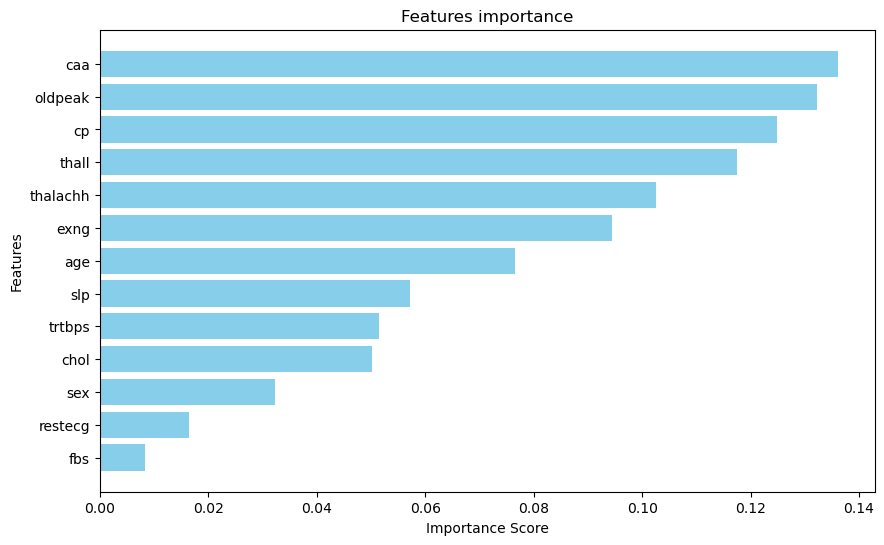

In [23]:
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances, color='skyblue')
plt.title("Features importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.show()